# Run 1: inject the best-fit wavelet modulation and recover it with RJMCMC

**Stage 3, run 1.** Before comparing the wavelet pipeline with Riccardo's chunked (OG) analysis, check that the
reversible-jump sampler recovers a modulation that the wavelet model can represent **exactly**. The injection is the
stage-2 least-squares fit of the true GF envelope over the 30-day pack-2 window
([wavelet_modulation_fit.ipynb](../wavelet_modulation_fit.ipynb), `wavelet_fit_reference.npz`), written in the inference
parametrisation ($b_A\equiv 0$ absorbed into the galactic amplitude):

$$\log P_A(t) = \sum_{k=1}^{2} a_k\,\psi\!\left(\tfrac{t-t_k}{\tau_k}\right),\qquad
\log P_E(t) = \ell_E + a_1\,\psi\!\left(\tfrac{t-t_1}{\tau_1}\right),\qquad \log_{10}A_{\rm gal} = \texttt{pack2\_amp\_eff}.$$

So the true model has **K_A = 2, K_E = 1**. The data are one continuous 30-day time series
$x_c(t) = n_c(t) + \sqrt{P_c(t)}\,g_c(t)$ (same noise/galaxy spectra and frequency band as Riccardo's pack-2 run, TDI
gen 1), transformed to the WDM domain. The sampler starts every walker at **K = 0** (spectral parameters in a small
ball around the truth), so the atoms have to be found by birth moves, not kept from the start.

All code that is not plotting lives in [injection.py](injection.py). Set `RERUN = True` to simulate and sample again
(about 35 min on 8 cores); otherwise the saved run in `outputs/run1/` is loaded.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
HERE = ROOT / 'data' / 'wavelet_injection'
sys.path.insert(0, str(HERE))
import injection as I
from bahamas.wavelet.model import WaveletData, DAY
from bahamas.wavelet import plotting

RERUN = False
OUT = HERE / 'outputs' / 'run1'
OUT.mkdir(parents=True, exist_ok=True)
CH = ['A', 'E']

C_TRUTH, C_POST, C_SECOND, C_MUTED, C_BAND = '#0b0b0b', '#2a78d6', '#eb6834', '#52514e', '#86b6ef'
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25, 'axes.spines.top': False,
                     'axes.spines.right': False, 'lines.linewidth': 1.5, 'legend.frameon': False})

cfg = I.CONFIG
print({k: v for k, v in cfg.items() if k not in ('wavelet', 'inference')})
print('wavelet  :', cfg['wavelet'])
print('inference:', cfg['inference'])

2026-10-09 15:54:54,390 - BAHAMAS - INFO - Using JAX backend.


2026-10-09 15:54:54,395 - BAHAMAS - INFO - np is from: jax.numpy


{'T': 2592000.0, 'dt': 10.0, 't0': 0.0, 'gen2': False, 'f1': 0.0001, 'f2': 0.029}
wavelet  : {'Nf': 4096, 'nx': 4.0, 'channels': [0, 1], 'seed': 2026, 'freq_bins': 200, 'edge_bins': 4, 'time_bin': 2, 'band_samples': 8}
inference: {'wavelet_shape': 'gaussian', 'min_wavelets': 0, 'max_wavelets': 8, 'width_range_days': [5.0, 60.0], 'amp_range': [-3.0, 3.0], 'level_range': [-3.0, 3.0], 'atom_step': 0.02, 'nwalkers': 32, 'ntemps': 4, 'nsteps': 6000, 'burnin': 2000, 'seed': 1}


## 1. The injection

The atoms were fitted with $t_{\rm frac}$ measured on $[0, 30\,{\rm d}]$. The posterior measures $t_{\rm frac}$ on the
span of the WDM grid, $[0, N\,\Delta t] = [0, 29.4\,{\rm d}]$ (an even number of 11.4 h time bins), so `remap_atoms`
re-expresses the same centres in that convention: the injected $P_c(t)$ is unchanged.

Shown for context: the true GF envelope $M_c^2(t)$ of stage 1, rescaled by $10^{\log_{10}A_{\rm true}-\log_{10}A_{\rm eff}}$
so that it is on the same scale as the injection. The two agree to ~0.3% rms (stage 2). The shaded edges are the time
bins dropped by the likelihood (`edge_bins = 4`, the transform wraps around).

In [2]:
ref = I.load_reference()
data, inj = I.load_or_simulate('wavelet', 'run1', rerun=RERUN)
like, post = I.build_posterior(data)
print(f'WDM grid: Nt = {data.Nt} x Nf = {data.Nf} (dT = {data.Nf * data.dt / 3600:.1f} h); likelihood: '
      f'{len(like.nu)} frequency groups x {len(like.times)} time groups x {len(data.channels)} channels')
print(f'analysed times: {like.times[0] / DAY:.2f} - {like.times[-1] / DAY:.2f} d (group centres)')

amp_true = I.true_amp()
print(f"amp: true GF {amp_true:.3f}, effective (injected) {ref['amp']:.3f};  level_E = {ref['level_E']:.3f}")
print('\ninjected atoms (posterior convention):')
for c in CH:
    for a in inj.atoms[c]:
        print(f'  {c}: centre {a[0] * inj.wm.T / DAY:6.2f} d (t_frac {a[0]:.4f}), width {10 ** a[1]:5.1f} d, amp {a[2]:+.3f}')

WDM grid: Nt = 62 x Nf = 4096 (dT = 11.4 h); likelihood: 178 frequency groups x 27 time groups x 2 channels


analysed times: 2.13 - 26.79 d (group centres)
amp: true GF -43.943, effective (injected) -43.267;  level_E = 0.443

injected atoms (posterior convention):
  A: centre   0.20 d (t_frac 0.0066), width  17.3 d, amp -2.407
  A: centre   4.01 d (t_frac 0.1364), width  14.7 d, amp +1.001
  E: centre   9.62 d (t_frac 0.3272), width  27.9 d, amp -1.069


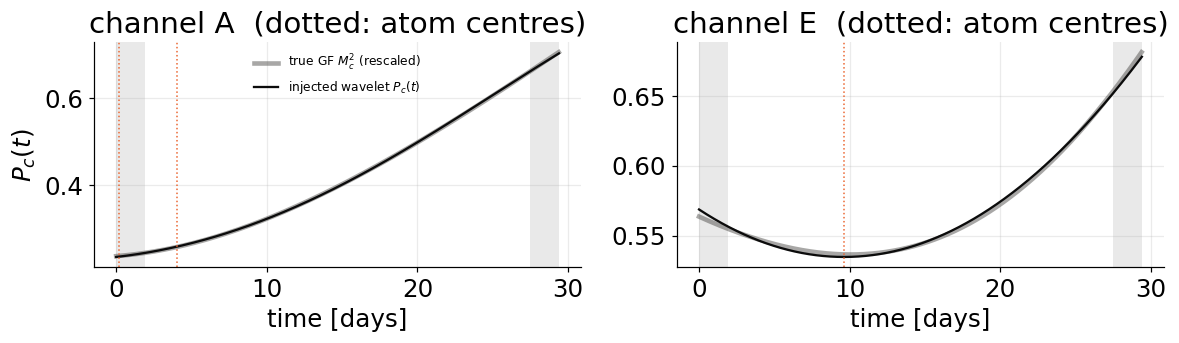

In [3]:
gf = np.load(ROOT / 'data' / 'cyclo_fig7_outputs' / 'gf_modulation_truth.npz')
t_fine = np.linspace(0, inj.wm.T, 2000)
scale = 10 ** (amp_true - ref['amp'])
dT = data.Nf * data.dt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharex=True)
for i, (ax, c) in enumerate(zip(axes, CH)):
    sel = gf['t_hour'] <= inj.wm.T
    ax.plot(gf['t_hour'][sel] / DAY, scale * gf[f'P_{c}'][sel], color=C_MUTED, lw=3, alpha=0.5, label=r'true GF $M_c^2$ (rescaled)')
    ax.plot(t_fine / DAY, np.asarray(inj.P(t_fine, i)), color=C_TRUTH, label='injected wavelet $P_c(t)$')
    for a in inj.atoms[c]:
        ax.axvline(a[0] * inj.wm.T / DAY, color=C_SECOND, ls=':', lw=1)
    lo, hi = data.times[cfg['wavelet']['edge_bins']], data.times[-cfg['wavelet']['edge_bins']]
    ax.axvspan(0, lo / DAY, color=C_MUTED, alpha=0.12, lw=0)
    ax.axvspan(hi / DAY, inj.wm.T / DAY, color=C_MUTED, alpha=0.12, lw=0)
    ax.set_title(f'channel {c}  (dotted: atom centres)')
    ax.set_xlabel('time [days]')
axes[0].set_ylabel(r'$P_c(t)$')
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / 'injection.png', dpi=150)

The first A atom (amp −2.4, width 17 d) is centred at day 0.2, inside the dropped edge: the data only see its
right-hand tail. That atom is therefore only weakly identifiable on its own; the combination of both A atoms over the
analysed window is what the data constrain.

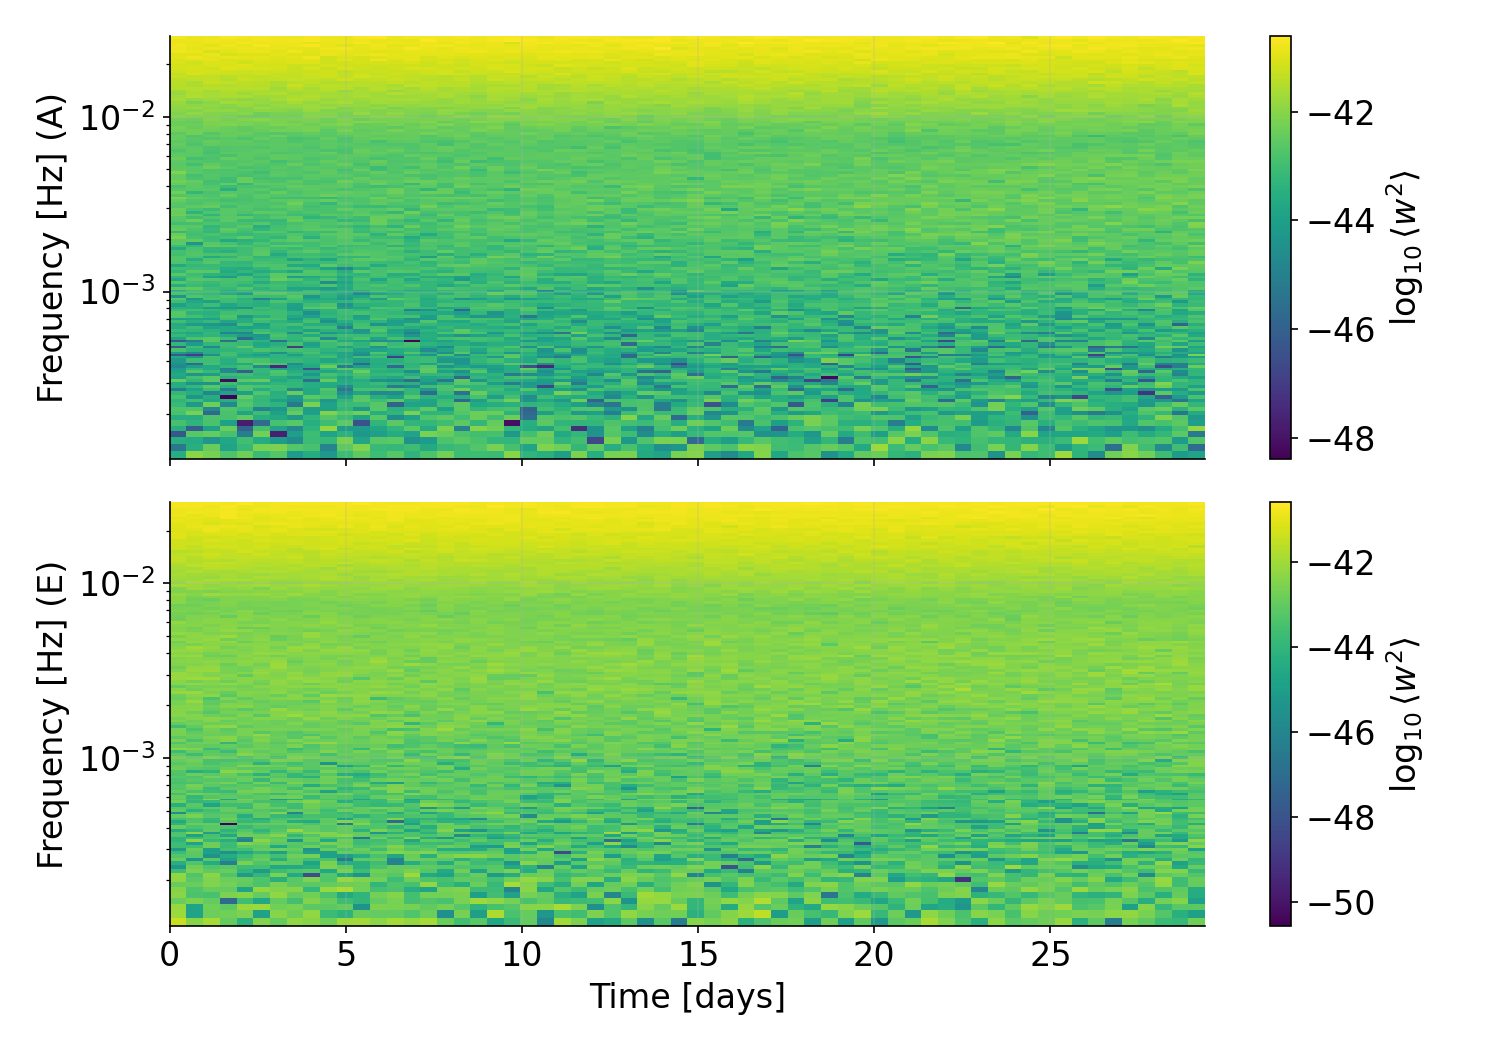

In [4]:
plotting.plot_spectrogram(data, cfg['f1'], cfg['f2'], str(OUT / 'data_spectrogram.png'))
display(Image(str(OUT / 'data_spectrogram.png'), width=700))

## 2. Sampling

eryn with reversible jump over the atoms of each channel (`mod_A`, `mod_E`) and a stretch move on the 8 spectral
parameters (`alpha, amp, fknee, fr1, fr2` of the galaxy, `A, P` of the noise, `level_E`). Priors: atom centre
$t_{\rm frac}\in[0,1]$, width 5–60 d (log-uniform), amplitude $\pm3$, $K\in[0,8]$ uniform, `level_E` $\in[-3,3]$, the
spectral bounds of `pe_pack2_cyclo.yaml`. 32 walkers × 4 temperatures, 2000 burn-in + 6000 stored steps.

In [5]:
res_path = OUT / 'chains.npz'
if RERUN or not res_path.exists():
    I.run('wavelet', 'run1')
r = dict(np.load(res_path, allow_pickle=True))
nsteps, nw = int(r['nsteps']), int(r['nwalkers'])
print(f"runtime {float(r['runtime_s']) / 60:.1f} min, {nsteps} steps x {nw} walkers (cold chain)")
print('acceptance (cold):', np.round(np.mean(r['acceptance_fraction']), 3),
      '| RJ acceptance (cold):', np.round(np.mean(r['rj_acceptance_fraction']), 3))

runtime 34.8 min, 6000 steps x 32 walkers (cold chain)
acceptance (cold): 0.072 | RJ acceptance (cold): 0.007


## 3. Convergence: number of atoms and log-likelihood

ln L - ln L_inj: median -1.42, max +4.28  (for ~17 free parameters a typical posterior sample sits ~8 below the max)


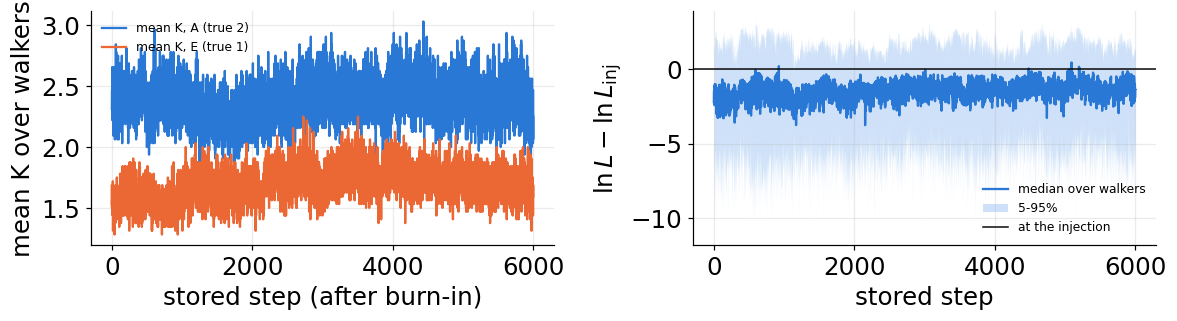

In [6]:
ll = r['log_like'].reshape(nsteps, nw)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for c, col in zip(CH, [C_POST, C_SECOND]):
    axes[0].plot(r[f'mod_{c}_nleaves'].reshape(nsteps, nw).mean(1), color=col, label=f'mean K, {c} (true {len(inj.atoms[c])})')
axes[0].set_xlabel('stored step (after burn-in)'); axes[0].set_ylabel('mean K over walkers'); axes[0].legend(fontsize=8)
axes[1].plot(np.median(ll, 1) - float(r['loglike_true']), color=C_POST, label='median over walkers')
axes[1].fill_between(np.arange(nsteps), *(np.percentile(ll, [5, 95], 1) - float(r['loglike_true'])), color=C_BAND, alpha=0.4, lw=0, label='5-95%')
axes[1].axhline(0, color=C_TRUTH, lw=1, label='at the injection')
axes[1].set_xlabel('stored step'); axes[1].set_ylabel(r'$\ln L - \ln L_{\rm inj}$'); axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / 'convergence.png', dpi=150)
d = ll.ravel() - float(r['loglike_true'])
print(f'ln L - ln L_inj: median {np.median(d):+.2f}, max {d.max():+.2f}  '
      f'(for ~{8 + 3 * 3} free parameters a typical posterior sample sits ~{(8 + 9) / 2:.0f} below the max)')

## 4. Posterior on the number of atoms

With a uniform prior on $K$, posterior odds are Bayes factors: $\ln\mathcal B(K, K') = \ln p(K|d) - \ln p(K'|d)$.

A p(K=1)=0.246 p(K=2)=0.359 p(K=3)=0.227 p(K=4)=0.113 p(K=5)=0.043 p(K=6)=0.010 p(K=7)=0.002 | ln B(K_true vs best other) = 0.38
E p(K=1)=0.494 p(K=2)=0.352 p(K=3)=0.123 p(K=4)=0.028 p(K=5)=0.002 p(K=6)=0.002 | ln B(K_true vs best other) = 0.34


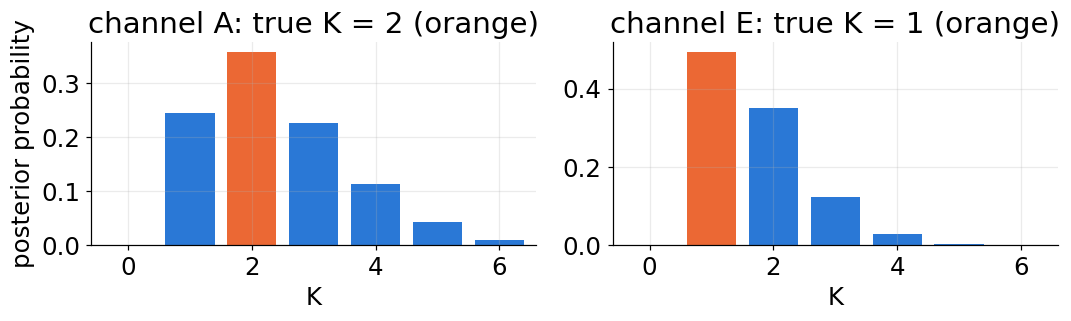

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for ax, c in zip(axes, CH):
    K, p = r[f'mod_{c}_bayes_K'], r[f'mod_{c}_bayes_posterior']
    ax.bar(K, p, color=[C_SECOND if k == len(inj.atoms[c]) else C_POST for k in K])
    ax.set_xlabel('K'); ax.set_title(f'channel {c}: true K = {len(inj.atoms[c])} (orange)')
    ax.set_xlim(-0.6, 6.6)
    print(c, ' '.join(f'p(K={k})={q:.3f}' for k, q in zip(K, p) if q > 1e-3),
          '| ln B(K_true vs best other) =', np.round(np.log(p[len(inj.atoms[c])]) - np.log(np.max(np.delete(p, len(inj.atoms[c])))), 2))
axes[0].set_ylabel('posterior probability')
fig.tight_layout()
fig.savefig(OUT / 'K_posterior.png', dpi=150)

## 5. Spectral parameters and `level_E`

param        truth    median        5%       95%  in 90%?  z
alpha        1.800     1.820     1.721     1.932  True   +0.31
amp        -43.267   -43.320   -43.439   -43.184  True   -0.67
fknee       -2.177    -2.175    -2.179    -2.171  True   +0.85
fr1         -2.429    -2.422    -2.436    -2.408  True   +0.81
fr2         -3.488    -3.505    -3.632    -3.400  True   -0.24
A            2.400     2.428     2.368     2.492  True   +0.74
P            7.900     7.900     7.878     7.922  True   -0.00
level_E      0.443     0.456     0.070     0.775  True   +0.06


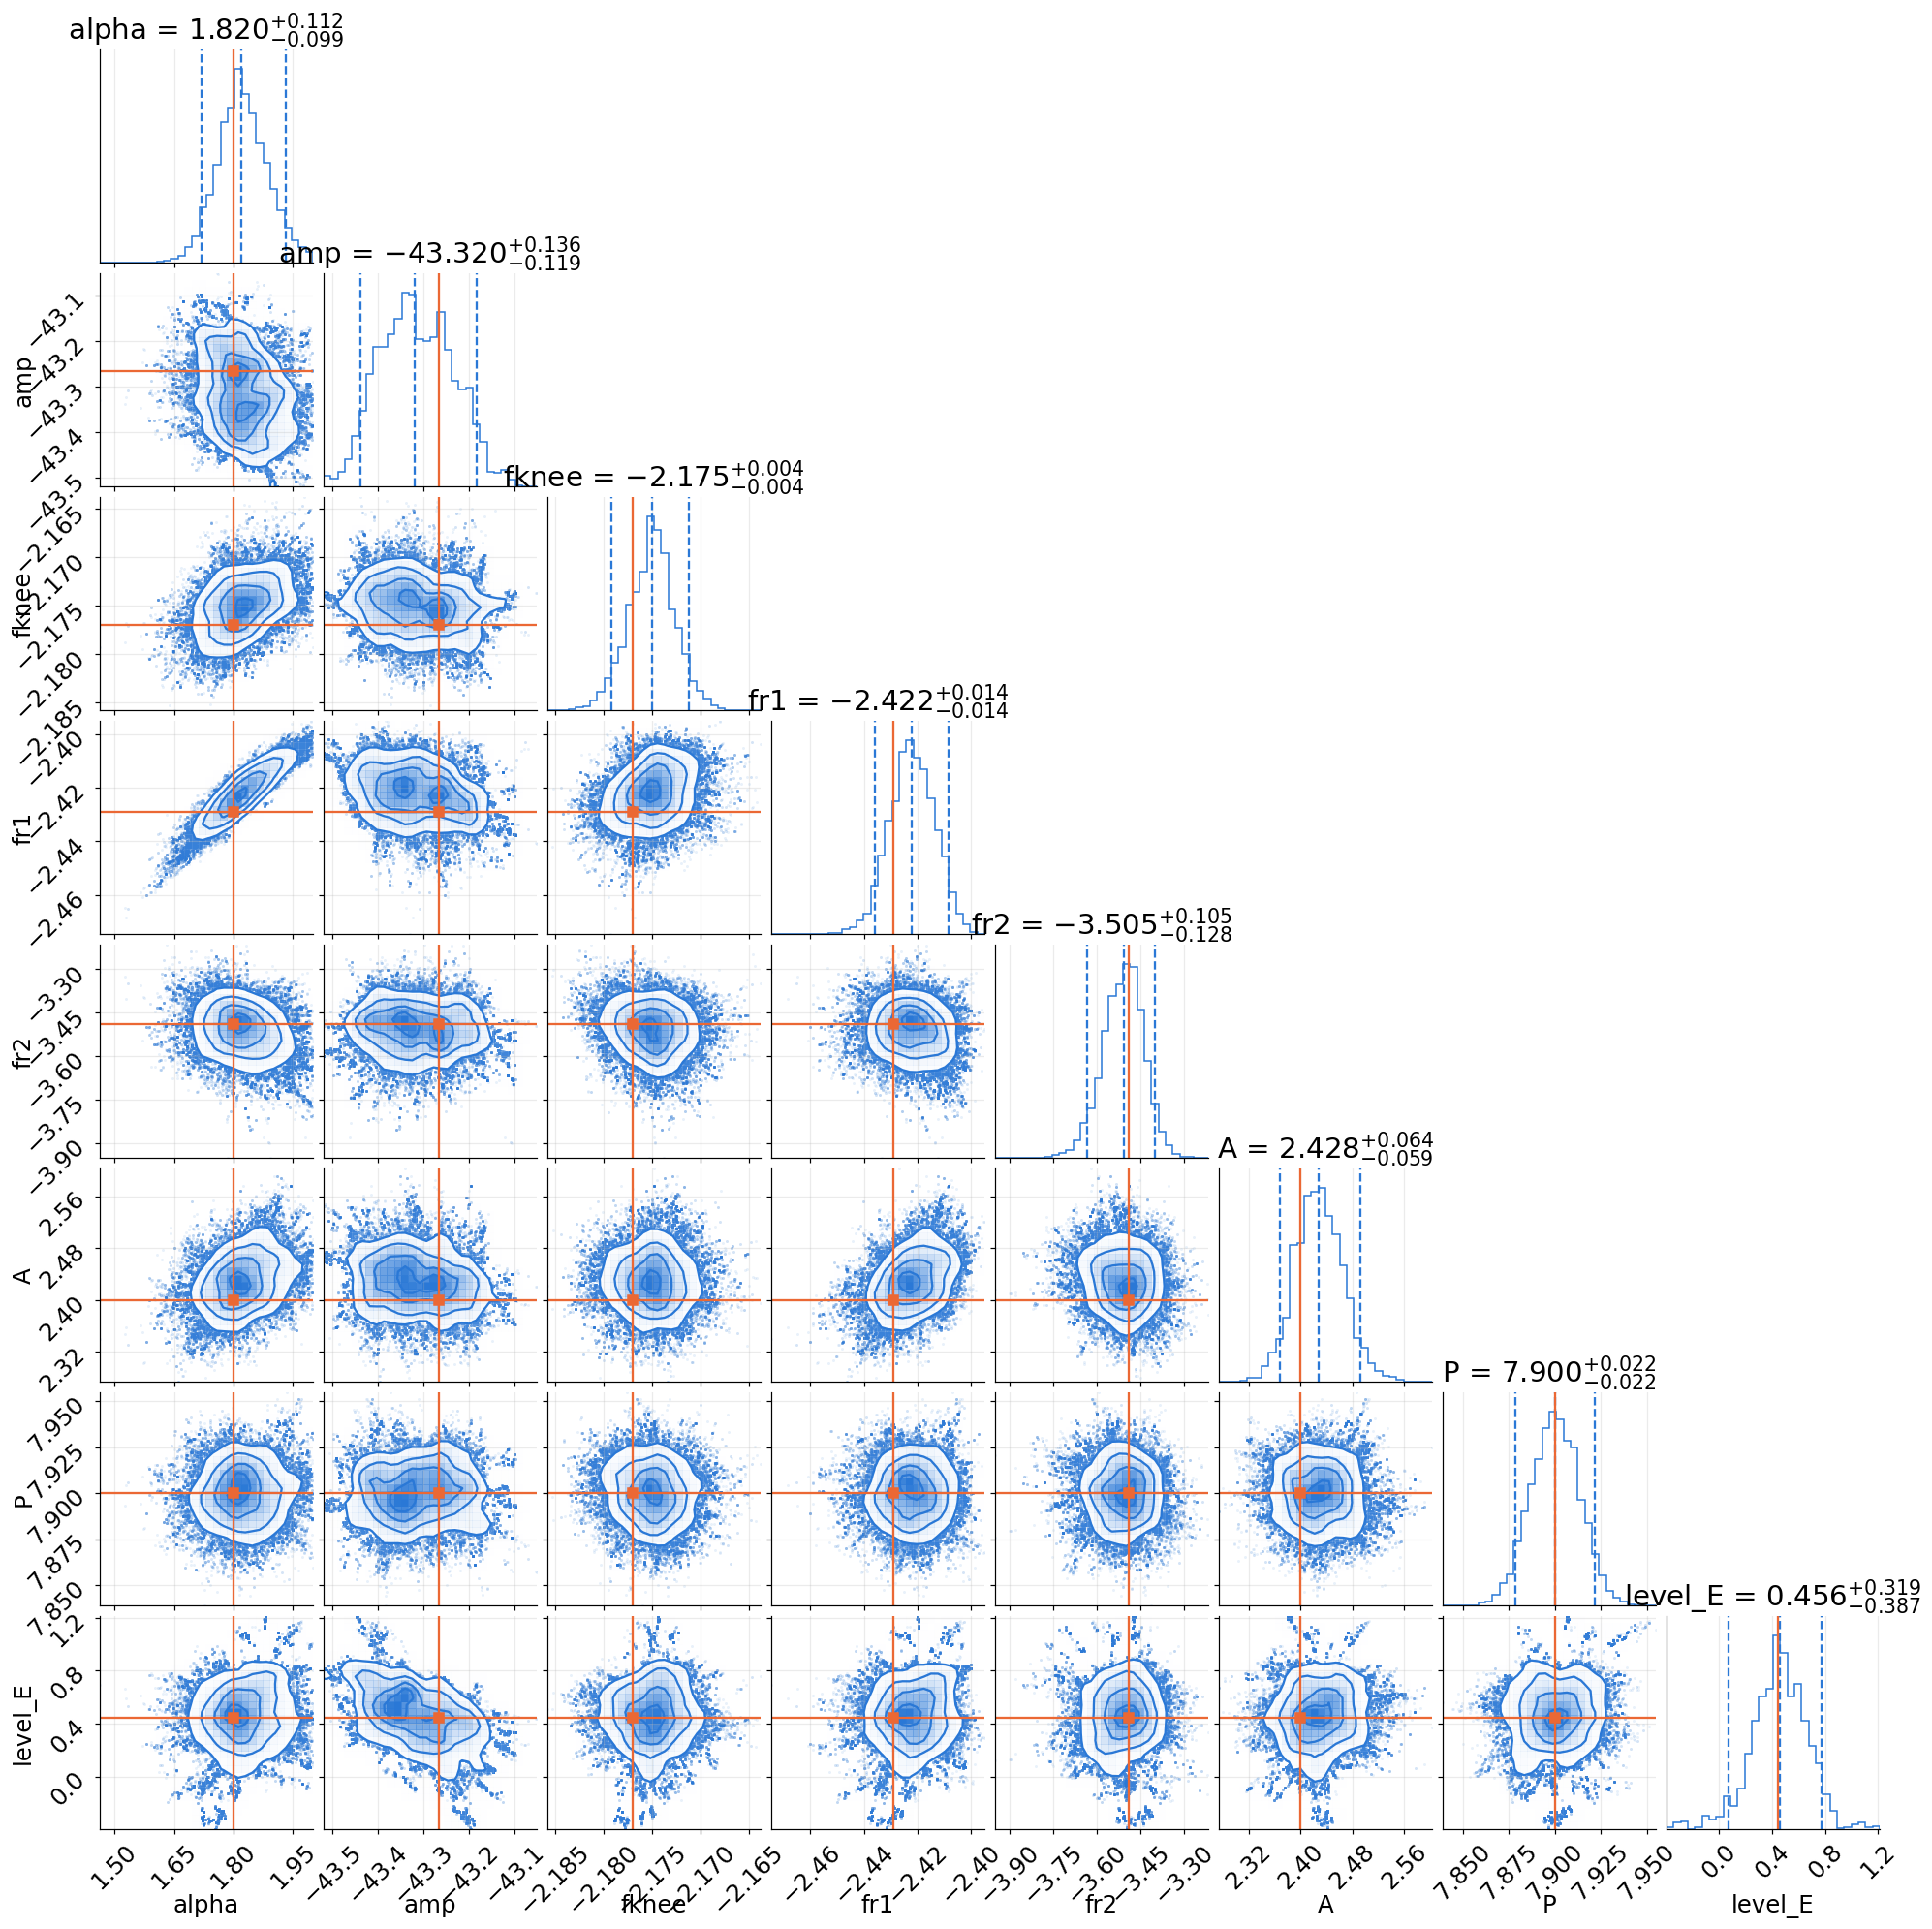

In [8]:
import corner
names = [str(n).split(':')[-1] for n in r['psd_names']]
fig = corner.corner(r['psd_chain'], labels=names, truths=r['psd_injected'], truth_color=C_SECOND, color=C_POST,
                    quantiles=[0.05, 0.5, 0.95], show_titles=True, title_fmt='.3f', bins=30, smooth=0.9)
fig.savefig(OUT / 'corner_psd.png', dpi=110)

print(f"{'param':8s} {'truth':>9s} {'median':>9s} {'5%':>9s} {'95%':>9s}  in 90%?  z")
for n, x, t in zip(names, r['psd_chain'].T, r['psd_injected']):
    q = np.percentile(x, [5, 50, 95])
    print(f'{n:8s} {t:9.3f} {q[1]:9.3f} {q[0]:9.3f} {q[2]:9.3f}  {str(q[0] <= t <= q[2]):5s}  {(q[1] - t) / np.std(x):+.2f}')

## 6. The atoms themselves

Atoms are exchangeable, so they are compared after sorting by centre, using only the samples with $K = K_{\rm true}$.
Atoms are not individually unique (an atom much wider than its neighbour trades off against it), so this plot is a
consistency check; §7 is the real test.

channel A: 68926 samples with K = 2
   atom 1 centre: 0.20 [0.14, 20.00] log10w: 1.24 [0.91, 1.73] amp: -2.41 [-1.98, -0.52]
   atom 2 centre: 4.01 [2.51, 28.58] log10w: 1.17 [0.87, 1.70] amp: 1.00 [-0.91, 1.32]


channel E: 94913 samples with K = 1
   atom 1 centre: 9.62 [2.97, 12.00] log10w: 1.45 [1.30, 1.66] amp: -1.07 [-1.32, -0.65]


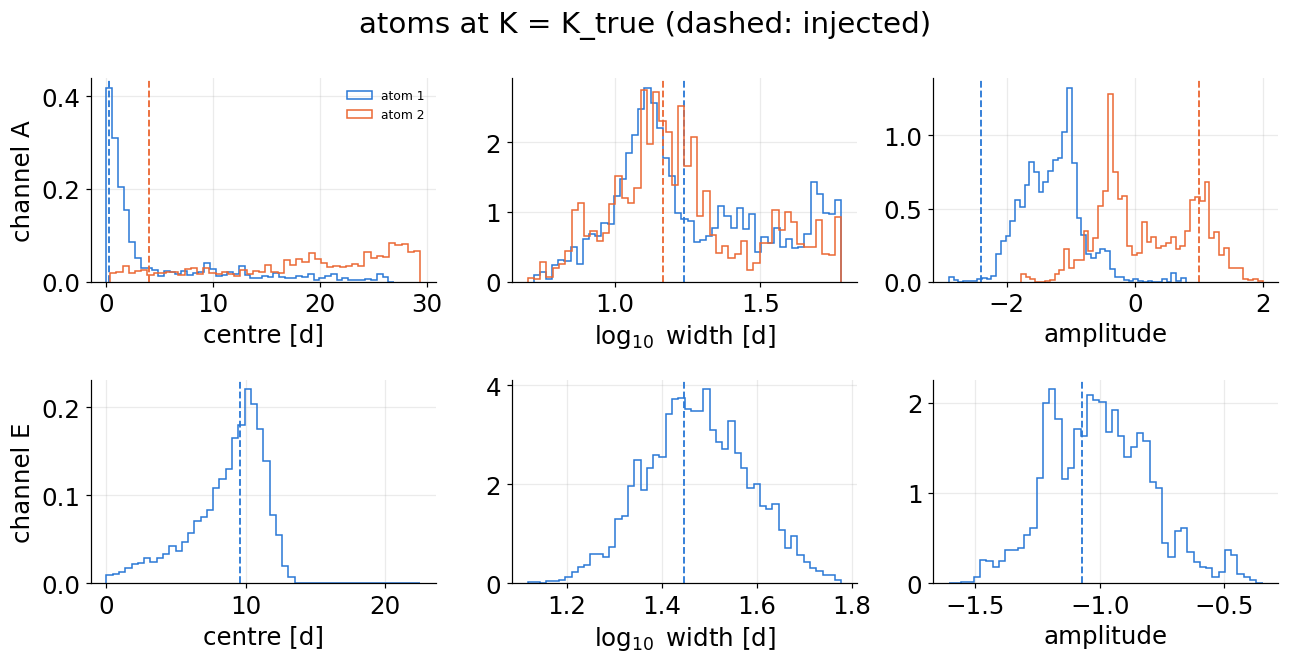

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6.2))
labels = ['centre [d]', r'$\log_{10}$ width [d]', 'amplitude']
for row, c in enumerate(CH):
    kt = len(inj.atoms[c])
    sel = r[f'mod_{c}_nleaves'] == kt
    A = r[f'mod_{c}_atoms'][sel]
    M = r[f'mod_{c}_inds'][sel]
    A = np.stack([a[m] for a, m in zip(A, M)])                      # (n, kt, 3)
    A = np.take_along_axis(A, np.argsort(A[:, :, 0], 1)[:, :, None], 1)
    A[:, :, 0] *= inj.wm.T / DAY
    truth = inj.atoms[c][np.argsort(inj.atoms[c][:, 0])].copy()
    truth[:, 0] *= inj.wm.T / DAY
    print(f'channel {c}: {sel.sum()} samples with K = {kt}')
    for j in range(kt):
        for p in range(3):
            ax = axes[row, p]
            ax.hist(A[:, j, p], bins=50, histtype='step', color=[C_POST, C_SECOND][j], density=True, label=f'atom {j + 1}')
            ax.axvline(truth[j, p], color=[C_POST, C_SECOND][j], ls='--', lw=1.2)
            ax.set_xlabel(labels[p])
        q = np.percentile(A[:, j], [5, 50, 95], axis=0)
        print('   atom', j + 1, ' '.join(f'{l.split(" ")[0]}: {t:.2f} [{a:.2f}, {b:.2f}]' for l, t, a, b in zip(['centre', 'log10w', 'amp'], truth[j], q[0], q[2])))
    axes[row, 0].set_ylabel(f'channel {c}')
axes[0, 0].legend(fontsize=8)
fig.suptitle('atoms at K = K_true (dashed: injected)')
fig.tight_layout()
fig.savefig(OUT / 'atoms.png', dpi=150)

## 7. The recovered modulation

Posterior draws of $10^{\log_{10}A-\log_{10}A_{\rm inj}}\,P_c(t)$: the galactic power relative to the injected
amplitude, which is what the data constrain (the overall level of $P_A$ is degenerate with the amplitude). Bands are
50% and 90%, over all $K$. Lower panels: fractional deviation from the injection.

A: injection inside the 90% band at 100% of analysed time bins; median 90% width = 11.1% of P
E: injection inside the 90% band at 100% of analysed time bins; median 90% width = 10.1% of P


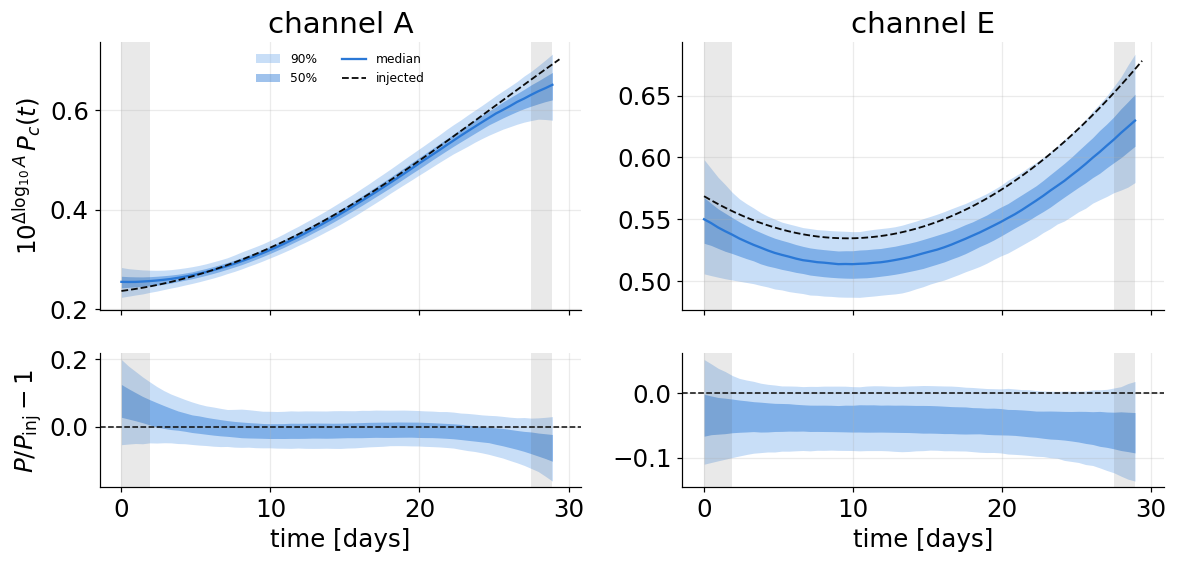

In [10]:
draws, t = r['modulation_draws'], r['modulation_times'] / DAY
q = np.percentile(draws, [5, 25, 50, 75, 95], axis=0)
P_true = r['P_true']
eb = cfg['wavelet']['edge_bins']
inside = slice(eb, len(t) - eb)

fig, axes = plt.subplots(2, 2, figsize=(11, 5.4), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
for i, c in enumerate(CH):
    ax, axr = axes[0, i], axes[1, i]
    ax.fill_between(t, q[0, i], q[4, i], color=C_BAND, alpha=0.45, lw=0, label='90%')
    ax.fill_between(t, q[1, i], q[3, i], color=C_POST, alpha=0.45, lw=0, label='50%')
    ax.plot(t, q[2, i], color=C_POST, label='median')
    ax.plot(t_fine / DAY, np.asarray(inj.P(t_fine, i)), color=C_TRUTH, ls='--', lw=1.2, label='injected')
    axr.fill_between(t, q[0, i] / P_true[i] - 1, q[4, i] / P_true[i] - 1, color=C_BAND, alpha=0.45, lw=0)
    axr.fill_between(t, q[1, i] / P_true[i] - 1, q[3, i] / P_true[i] - 1, color=C_POST, alpha=0.45, lw=0)
    axr.axhline(0, color=C_TRUTH, ls='--', lw=1)
    for a in (ax, axr):
        a.axvspan(t[0], t[eb], color=C_MUTED, alpha=0.12, lw=0)
        a.axvspan(t[-eb], t[-1], color=C_MUTED, alpha=0.12, lw=0)
    ax.set_title(f'channel {c}')
    axr.set_xlabel('time [days]')
    cover = np.mean((q[0, i, inside] <= P_true[i, inside]) & (P_true[i, inside] <= q[4, i, inside]))
    width = np.median((q[4, i, inside] - q[0, i, inside]) / P_true[i, inside])
    print(f'{c}: injection inside the 90% band at {100 * cover:.0f}% of analysed time bins; median 90% width = {100 * width:.1f}% of P')
axes[0, 0].set_ylabel(r'$10^{\Delta\log_{10}A}\,P_c(t)$')
axes[1, 0].set_ylabel(r'$P/P_{\rm inj} - 1$')
axes[0, 0].legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(OUT / 'modulation_recovery.png', dpi=150)

## 8. Summary

The numbers printed above are collected in [reports/WAVELET_INJECTION_RUN1.md](../../reports/WAVELET_INJECTION_RUN1.md).
Run 2 (inject the true sky envelope, compare $P_c(t)$ bands with the OG chunked posterior):
[run2_sky_vs_og.ipynb](run2_sky_vs_og.ipynb).